<style>
@page { size: Letter landscape; margin: 0.35in; }
body { color: #1d1d1f; }
@media print {
  .jp-CodeCell .jp-Cell-inputWrapper, div.input_area, div.prompt { display: none !important; }
  body { font-size: 10px; }
  h1 { font-size: 22px; }
  h2 { font-size: 17px; margin-top: 14px; }
  h3 { font-size: 14px; }
}
table.dataframe { border-collapse: collapse; width: 100%; table-layout: auto; font-size: 8.4px; }
table.dataframe th, table.dataframe td { border: 1px solid #d8d8d8; padding: 3px 4px; text-align: right; white-space: normal; word-break: normal; }
table.dataframe th:first-child, table.dataframe td:first-child { text-align: left; }
table.dataframe caption { caption-side: top; text-align: left; font-weight: 600; margin: 6px 0; font-size: 10px; }
.logo-row { width:100%; display:flex; justify-content:center; align-items:center; gap:54px; padding:12px 0 18px 0; page-break-inside:avoid; break-inside:avoid; }
.logo-row img { display:block; object-fit:contain; height:auto; width:auto; }
.logo-app { max-height:190px; max-width:190px; }
.logo-journal { max-height:190px; max-width:190px; border-radius:50%; }
.eqbox { text-align:center; font-size:18px; line-height:1.75; margin:14px 0 10px; }
.note { font-size: 12px; color:#333; }
</style>
<div class="logo-row">
  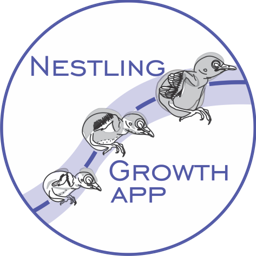
  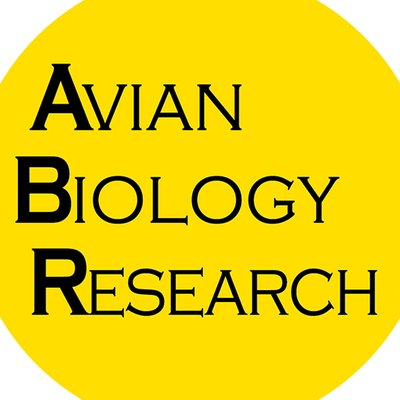
</div>


# Supplementary S4. Predictive validation of AICc-supported growth models

This analysis evaluates whether the growth models receiving the strongest AICc support also predict observations that were not used during model fitting. The evaluation is focused on the two larger non-passerine datasets, where the data structure allows a meaningful predictive check: *Tachymarptis melba* and *Megadyptes antipodes*.

For *T. melba*, the main test is a repeated grouped cross-validation by nest. This keeps nest-related observations together, so that a nest can contribute either to model fitting or to prediction, but never to both within the same fold. Two sensitivity checks then repeat the same idea by ring and by year. For *M. antipodes*, the data are evaluated across observed age classes, which tests how stable the fitted trajectory is when parts of the age series are withheld.

The interpretation is intentionally measured. AICc gives relative support among candidate models within the fitted data; the checks below ask whether that support is also reflected in held-out predictive performance.


## Data used in the validation

The *T. melba* analysis starts from the longitudinal measurement file and links it by ring to the local nest metadata. The linked set is used for the nest- and year-grouped checks, while the full longitudinal file is used for the ring-grouped sensitivity check. The *M. antipodes* analysis starts from the 720 measurements and summarises them by observed age before fitting and validation.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from scipy.optimize import OptimizeWarning, curve_fit

SEED = 20260721
ROOT = Path(r"D:\Growthrate\Nestling")
R2_OUT = Path(r"D:\Growt Rate\R2\Supplementary_S4_predictive_validation")
DATA = R2_OUT / "data"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 220, "font.size": 10})

MODEL_ORDER = ["Richards", "Gompertz", "Extreme Value Function", "Logistic", "Von Bertalanffy"]
SHORT_NAMES = {"Extreme Value Function": "EVF", "Von Bertalanffy": "VB"}
TRAIT_UNITS = {"mass": "g", "wing": "mm", "tarsus": "mm"}

def show_table(df, caption=None, digits=4):
    out = df.copy()
    for col in out.select_dtypes(include=["float", "float64", "float32"]).columns:
        out[col] = out[col].round(digits)
    styler = out.style.hide(axis="index")
    if caption:
        styler = styler.set_caption(caption)
    display(styler)


In [2]:
official = pd.read_csv(DATA / "data_nestlings-all-meas.csv").reset_index().rename(columns={"index": "row_id"})
official["row_id"] = "osf_" + official["row_id"].astype(str)
metadata = pd.read_csv(DATA / "data_nestlings.csv")
metadata_core = metadata[["ring", "year", "colony", "nestcode_rearing"]].drop_duplicates("ring")
linked = official.merge(metadata_core, on="ring", how="inner")
penguin = pd.read_csv(DATA / "yellow-eyed penguin.csv")
penguin_means = (
    penguin.groupby("Age_days", as_index=False)
    .agg(
        Weight_g=("Weight_g", "mean"),
        Flipper_length_mm=("Flipper_length_mm", "mean"),
        Foot_length_mm=("Foot_length_mm", "mean"),
        Raw_rows=("Weight_g", "size"),
    )
    .sort_values("Age_days")
)

counts = pd.DataFrame([
    {"Dataset": "Tachymarptis melba, full longitudinal file", "Rows": len(official), "Individuals/rings": official["ring"].nunique(), "Nests": np.nan, "Age classes": official["age_days"].nunique(), "Mass records": official["mass"].notna().sum(), "Wing records": official["wing"].notna().sum()},
    {"Dataset": "Tachymarptis melba, linked to nest metadata", "Rows": len(linked), "Individuals/rings": linked["ring"].nunique(), "Nests": linked["nestcode_rearing"].nunique(), "Age classes": linked["age_days"].nunique(), "Mass records": linked["mass"].notna().sum(), "Wing records": linked["wing"].notna().sum()},
    {"Dataset": "Megadyptes antipodes, measurements", "Rows": len(penguin), "Individuals/rings": np.nan, "Nests": np.nan, "Age classes": penguin["Age_days"].nunique(), "Mass records": penguin["Weight_g"].notna().sum(), "Wing records": penguin["Flipper_length_mm"].notna().sum()},
    {"Dataset": "Megadyptes antipodes, age-class means", "Rows": len(penguin_means), "Individuals/rings": np.nan, "Nests": np.nan, "Age classes": penguin_means["Age_days"].nunique(), "Mass records": penguin_means["Weight_g"].notna().sum(), "Wing records": penguin_means["Flipper_length_mm"].notna().sum()},
])
show_table(counts, "Table S4.1. Data used for the predictive validation", digits=0)

assert len(official) == 16148
assert official["ring"].nunique() == 3195
assert official["mass"].notna().sum() == 15967
assert official["wing"].notna().sum() == 15865
assert metadata["ring"].nunique() == 2693
assert linked["nestcode_rearing"].nunique() == 1307
assert len(penguin) == 720
assert penguin["Age_days"].nunique() == 25


Dataset,Rows,Individuals/rings,Nests,Age classes,Mass records,Wing records
"Tachymarptis melba, full longitudinal file",16148,3195.000000,nan,75,15967,15865
"Tachymarptis melba, linked to nest metadata",14664,2693.000000,1307.000000,75,14582,14510
"Megadyptes antipodes, measurements",720,nan,nan,25,720,720
"Megadyptes antipodes, age-class means",25,nan,nan,25,25,25


## Model equations and information criteria

Five sigmoidal growth models were fitted to each trait. Their notation is kept compact here because the purpose of this analysis is predictive behaviour rather than re-describing the models.

<div class="eqbox" style="text-align:left; max-width:780px; margin:16px auto; font-size:16px; line-height:2.0;">
  <div><b>Logistic:</b> <i>y</i>(<i>t</i>) = <i>A</i> / (1 + exp(-<i>k</i>(<i>t</i> - <i>T</i>)))</div>
  <div><b>Gompertz:</b> <i>y</i>(<i>t</i>) = <i>A</i> exp[-<i>b</i> exp(-<i>c</i><i>t</i>)]</div>
  <div><b>Richards:</b> <i>y</i>(<i>t</i>) = <i>A</i> / (1 + exp(-<i>k</i>(<i>t</i> - <i>T</i>)))<sup>1/<i>v</i></sup></div>
  <div><b>von Bertalanffy:</b> <i>y</i>(<i>t</i>) = <i>A</i>(1 - exp(-<i>k</i>(<i>t</i> - <i>t</i><sub>0</sub>)))</div>
  <div><b>Extreme value function:</b> <i>y</i>(<i>t</i>) = <i>A</i> exp[-<i>b</i> exp(-<i>c</i><i>t</i>)] (1 - exp(-<i>d</i><i>t</i>))</div>
</div>

For each fitted model, AIC, AICc and BIC were calculated from the residual sum of squares. AICc was used for ranking because it adds the small-sample correction to AIC:

<div class="eqbox" style="font-size:17px; line-height:2.1; text-align:center; margin:16px 0;">
  <div><i>AIC</i> = <i>n</i> log(<i>SSE</i>/<i>n</i>) + 2<i>K</i></div>
  <div><i>AICc</i> = <i>AIC</i> +
    <span style="display:inline-block; vertical-align:middle; text-align:center; margin:0 5px;">
      <span style="display:block; border-bottom:1px solid #222; padding:0 8px;">2<i>K</i>(<i>K</i> + 1)</span>
      <span style="display:block; padding:0 8px;"><i>n</i> - <i>K</i> - 1</span>
    </span>
  </div>
  <div><i>BIC</i> = <i>n</i> log(<i>SSE</i>/<i>n</i>) + <i>K</i> log(<i>n</i>)</div>
</div>

Here, <i>n</i> is the number of observations used for fitting and <i>K</i> is the number of fitted parameters. When <i>n</i> <= <i>K</i> + 1, AICc is undefined and the value is treated as unavailable for ranking.


In [3]:
def exp_clip(z):
    return np.exp(np.clip(z, -700, 700))


def logistic(x, a, k, x0):
    return a / (1.0 + exp_clip(-k * (x - x0)))


def gompertz(x, a, b, c):
    return a * exp_clip(-b * exp_clip(-c * x))


def richards(x, a, k, x0, v):
    return a / (1.0 + exp_clip(-k * (x - x0))) ** (1.0 / v)


def von_bertalanffy(x, l_inf, k, t0):
    return l_inf * (1.0 - exp_clip(-k * (x - t0)))


def evf(x, a, b, c, d):
    return a * exp_clip(-b * exp_clip(-c * x)) * (1.0 - exp_clip(-d * x))


@dataclass(frozen=True)
class ModelSpec:
    name: str
    func: Callable
    param_names: tuple[str, ...]


MODEL_SPECS = [
    ModelSpec("Logistic", logistic, ("A", "k", "T")),
    ModelSpec("Gompertz", gompertz, ("A", "b", "c")),
    ModelSpec("Richards", richards, ("A", "k", "T", "v")),
    ModelSpec("Von Bertalanffy", von_bertalanffy, ("A", "k", "t0")),
    ModelSpec("Extreme Value Function", evf, ("A", "b", "c", "d")),
]


def information_criteria(y_true, y_pred, params) -> tuple[float, float, float, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residuals = y_true - y_pred
    sse = float(np.sum(residuals**2))
    n = int(y_true.size)
    k = int(len(params))
    safe_sse = max(sse, np.finfo(float).tiny)
    aic = float(n * np.log(safe_sse / n) + 2 * k)
    aicc = math.inf
    if n > k + 1:
        aicc = float(aic + (2 * k * (k + 1)) / (n - k - 1))
    bic = float(n * np.log(safe_sse / n) + k * np.log(n))
    return sse, aic, aicc, bic


def k_and_t(model: str, params: np.ndarray) -> tuple[float, float]:
    try:
        if model == "Logistic":
            return float(params[1]), float(params[2])
        if model == "Gompertz":
            return float(params[2]), float(np.log(params[1]) / params[2])
        if model == "Richards":
            return float(params[1]), float(params[2])
        if model == "Von Bertalanffy":
            return float(params[1]), float(params[2])
        if model == "Extreme Value Function":
            return float(params[2]), float(np.log(params[1]) / params[2])
    except Exception:
        return math.nan, math.nan
    return math.nan, math.nan


def parameter_dict(spec: ModelSpec, params: np.ndarray) -> dict:
    return {name: float(value) for name, value in zip(spec.param_names, params)}


def fit_bounds(model: str, x: np.ndarray, y: np.ndarray) -> tuple[list[float], list[float]]:
    ymax = max(float(np.nanmax(y)), 1e-6)
    xmin = float(np.nanmin(x))
    xmax = float(np.nanmax(x))
    span = max(xmax - xmin, 1.0)
    lo_age = xmin - 2.0 * span - 10.0
    hi_age = xmax + 2.0 * span + 10.0
    a_hi = max(ymax * 5.0, ymax + 10.0)
    if model == "Logistic":
        return [1e-9, 1e-6, lo_age], [a_hi, 5.0, hi_age]
    if model == "Gompertz":
        return [1e-9, 1e-9, 1e-6], [a_hi, 100.0, 5.0]
    if model == "Richards":
        return [1e-9, 1e-6, lo_age, 0.02], [a_hi, 5.0, hi_age, 50.0]
    if model == "Von Bertalanffy":
        return [1e-9, 1e-6, lo_age], [a_hi, 5.0, hi_age]
    if model == "Extreme Value Function":
        return [1e-9, 1e-9, 1e-6, 1e-6], [a_hi, 100.0, 5.0, 5.0]
    raise ValueError(model)


def _clip_start(p0: list[float], bounds: tuple[list[float], list[float]]) -> list[float]:
    lo, hi = np.asarray(bounds[0], dtype=float), np.asarray(bounds[1], dtype=float)
    p0a = np.asarray(p0, dtype=float)
    eps = np.maximum((hi - lo) * 1e-6, 1e-8)
    return np.minimum(np.maximum(p0a, lo + eps), hi - eps).tolist()


def make_starts(model: str, x: np.ndarray, y: np.ndarray) -> list[list[float]]:
    ymax = max(float(np.nanmax(y)), 1e-6)
    xmin = float(np.nanmin(x))
    xmax = float(np.nanmax(x))
    span = max(xmax - xmin, 1.0)
    q25, q50, q75 = np.quantile(x, [0.25, 0.5, 0.75])
    a_vals = [max(ymax * f, 1e-6) for f in (0.9, 1.0, 1.15, 1.35, 1.7)]
    k_vals = [0.02, 0.04, 0.08, 0.12, 0.2, 0.35]
    t_vals = [q25, q50, q75, xmin + 0.15 * span, xmin + 0.85 * span]
    b_vals = [0.5, 1.0, 2.0, 4.0, 8.0]
    c_vals = [0.02, 0.04, 0.08, 0.12, 0.2]
    d_vals = [0.02, 0.05, 0.1, 0.2, 0.4]
    v_vals = [0.25, 0.5, 0.8, 1.0, 1.5, 3.0, 6.0]
    starts: list[list[float]] = []
    if model == "Logistic":
        starts = [[a, k, t] for a in a_vals[:3] for k in k_vals[:3] for t in t_vals[:3]]
    elif model == "Gompertz":
        starts = [[a, b, c] for a in a_vals[:3] for b in b_vals[:3] for c in c_vals[:3]]
    elif model == "Von Bertalanffy":
        starts = [[a, k, xmin - offset] for a in a_vals[:3] for k in k_vals[:3] for offset in (1.0, 5.0, 10.0)]
    elif model == "Richards":
        starts = [[a, k, t, v] for a in a_vals for k in k_vals[:5] for t in t_vals for v in v_vals]
    elif model == "Extreme Value Function":
        starts = [[a, b, c, d] for a in a_vals for b in b_vals for c in c_vals for d in d_vals]
    else:
        raise ValueError(model)
    bounds = fit_bounds(model, x, y)
    clipped = [_clip_start(p, bounds) for p in starts]
    if model in {"Richards", "Extreme Value Function"}:
        return clipped[:25]
    return clipped[:12]


def fit_one_model(spec: ModelSpec, x: np.ndarray, y: np.ndarray) -> dict:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    bounds = fit_bounds(spec.name, x, y)
    starts = make_starts(spec.name, x, y)
    best = None
    warning_messages: list[str] = []
    successes = 0
    for p0 in starts:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always", OptimizeWarning)
                popt, _ = curve_fit(
                    spec.func,
                    x,
                    y,
                    p0=p0,
                    bounds=bounds,
                    method="trf",
                    max_nfev=20000,
                    x_scale="jac",
                )
                warning_messages.extend(str(w.message) for w in caught)
            yhat = spec.func(x, *popt)
            if not np.all(np.isfinite(yhat)):
                continue
            sse, aic, aicc, bic = information_criteria(y, yhat, popt)
            if not np.isfinite(aic):
                continue
            successes += 1
            if best is None or sse < best["SSE"]:
                best = {
                    "Model": spec.name,
                    "n": int(len(y)),
                    "Parameter_count": int(len(popt)),
                    "SSE": sse,
                    "AIC": aic,
                    "AICc": aicc,
                    "BIC": bic,
                    "Parameters": parameter_dict(spec, popt),
                    "Parameter_vector": [float(v) for v in popt],
                    "Converged": True,
                }
        except Exception as exc:
            warning_messages.append(f"{type(exc).__name__}: {exc}")
    if best is None:
        k = len(spec.param_names)
        best = {
            "Model": spec.name,
            "n": int(len(y)),
            "Parameter_count": k,
            "SSE": math.inf,
            "AIC": math.inf,
            "AICc": math.inf,
            "BIC": math.inf,
            "Parameters": {},
            "Parameter_vector": [math.nan] * k,
            "Converged": False,
        }
    k_value, t_value = k_and_t(spec.name, np.asarray(best["Parameter_vector"], dtype=float))
    best["k_or_c"] = k_value
    best["T_or_t0"] = t_value
    best["Starts_attempted"] = len(starts)
    best["Successful_starts"] = successes
    best["Warnings"] = "; ".join(dict.fromkeys(warning_messages[:8]))
    return best


def fit_candidate_set(x: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    rows = [fit_one_model(spec, x, y) for spec in MODEL_SPECS]
    df = pd.DataFrame(rows)
    finite = df["AICc"].replace([np.inf, -np.inf], np.nan)
    best = finite.min()
    df["Delta_AICc"] = df["AICc"] - best
    weights = np.exp(-0.5 * df["Delta_AICc"].replace([np.inf, -np.inf], np.nan))
    weight_sum = weights.sum(skipna=True)
    df["Akaike_weight"] = weights / weight_sum if weight_sum and np.isfinite(weight_sum) else np.nan
    df["AICc_rank"] = df["AICc"].rank(method="min", na_option="bottom")
    df["Parameters_json"] = df["Parameters"].apply(lambda d: json.dumps(d, sort_keys=True))
    return df.sort_values(["AICc", "AIC"]).reset_index(drop=True)


def clean_xy(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    out = df[[c for c in df.columns if c in {x_col, y_col, "row_id", "ring", "nestcode_rearing", "year", "colony", "Age_days"}]].copy()
    out[x_col] = pd.to_numeric(out[x_col], errors="coerce")
    out[y_col] = pd.to_numeric(out[y_col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, y_col])
    return out


def predict_with_row(row: pd.Series, x: np.ndarray) -> np.ndarray:
    spec = next(spec for spec in MODEL_SPECS if spec.name == row["Model"])
    params = row["Parameter_vector"]
    return spec.func(np.asarray(x, dtype=float), *params)


def metric_values(y: np.ndarray, pred: np.ndarray) -> dict:
    err = pred - y
    sse = float(np.sum(err**2))
    denom = float(np.sum((y - np.mean(y)) ** 2))
    return {
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "Bias": float(np.mean(err)),
        "Predictive_R2": float(1.0 - sse / denom) if denom > 0 else math.nan,
    }


def balanced_metric_values(test: pd.DataFrame, pred: np.ndarray, y_col: str, group_col: str) -> dict:
    tmp = test[[group_col, y_col]].copy()
    tmp["pred"] = pred
    per_group = []
    for _, g in tmp.groupby(group_col, dropna=False):
        y = g[y_col].to_numpy(dtype=float)
        p = g["pred"].to_numpy(dtype=float)
        vals = metric_values(y, p)
        vals["Group_n"] = int(len(g))
        per_group.append(vals)
    if not per_group:
        return {"Balanced_RMSE": math.nan, "Balanced_MAE": math.nan, "Balanced_Bias": math.nan, "Balanced_Predictive_R2": math.nan}
    pdf = pd.DataFrame(per_group)
    return {
        "Balanced_RMSE": float(pdf["RMSE"].mean()),
        "Balanced_MAE": float(pdf["MAE"].mean()),
        "Balanced_Bias": float(pdf["Bias"].mean()),
        "Balanced_Predictive_R2": float(pdf["Predictive_R2"].mean(skipna=True)),
    }


def group_kfold_indices(df: pd.DataFrame, group_col: str, repeats: int = 10, folds: int = 5, seed: int = SEED):
    groups = pd.Series(df[group_col].dropna().unique()).astype(str).to_numpy()
    if len(groups) < folds:
        raise ValueError(f"Need at least {folds} groups for {group_col}; found {len(groups)}")
    for repeat in range(1, repeats + 1):
        rng = np.random.default_rng(seed + repeat * 1009 + len(groups))
        shuffled = groups.copy()
        rng.shuffle(shuffled)
        assignments = {group: i % folds for i, group in enumerate(shuffled)}
        group_values = df[group_col].astype(str)
        for fold in range(folds):
            test_mask = group_values.map(assignments).eq(fold).to_numpy()
            train_mask = ~test_mask
            yield repeat, fold + 1, train_mask, test_mask


def run_grouped_cv(
    data: pd.DataFrame,
    species: str,
    trait: str,
    y_col: str,
    group_col: str,
    scheme: str,
    repeats: int = 10,
    folds: int = 5,
) -> tuple[pd.DataFrame, list[dict]]:
    trait_df = clean_xy(data, "age_days", y_col)
    trait_df = trait_df.dropna(subset=[group_col]).copy()
    trait_df["group_value"] = trait_df[group_col].astype(str)
    rows: list[dict] = []
    overlap_checks: list[dict] = []
    for repeat, fold, train_mask, test_mask in group_kfold_indices(trait_df, group_col, repeats=repeats, folds=folds):
        train = trait_df.loc[train_mask].copy()
        test = trait_df.loc[test_mask].copy()
        train_groups = set(train[group_col].astype(str))
        test_groups = set(test[group_col].astype(str))
        train_rows = set(train["row_id"].astype(str)) if "row_id" in train else set(train.index.astype(str))
        test_rows = set(test["row_id"].astype(str)) if "row_id" in test else set(test.index.astype(str))
        overlap = train_groups & test_groups
        row_overlap = train_rows & test_rows
        if overlap or row_overlap:
            raise AssertionError(f"Leakage in {scheme} repeat {repeat} fold {fold}")
        overlap_checks.append(
            {
                "Species": species,
                "Trait": trait,
                "Scheme": scheme,
                "Group_column": group_col,
                "Repeat": repeat,
                "Fold": fold,
                "Train_groups": len(train_groups),
                "Test_groups": len(test_groups),
                "Group_overlap": len(overlap),
                "Row_overlap": len(row_overlap),
                "Train_rows": int(len(train)),
                "Test_rows": int(len(test)),
            }
        )
        fit_table = fit_candidate_set(train["age_days"].to_numpy(), train[y_col].to_numpy())
        aicc_winner = fit_table.iloc[0]["Model"]
        for _, model_row in fit_table.iterrows():
            pred = predict_with_row(model_row, test["age_days"].to_numpy())
            obs_metrics = metric_values(test[y_col].to_numpy(dtype=float), pred)
            bal_metrics = balanced_metric_values(test, pred, y_col, group_col)
            rows.append(
                {
                    "Species": species,
                    "Trait": trait,
                    "Scheme": scheme,
                    "Group_column": group_col,
                    "Repeat": repeat,
                    "Fold": fold,
                    "Model": model_row["Model"],
                    "AICc_winner": aicc_winner,
                    "Train_n": int(len(train)),
                    "Test_n": int(len(test)),
                    "Train_groups": len(train_groups),
                    "Test_groups": len(test_groups),
                    "Train_AICc": float(model_row["AICc"]),
                    "Train_Delta_AICc": float(model_row["Delta_AICc"]),
                    "AICc_rank": int(model_row["AICc_rank"]),
                    "Converged": bool(model_row["Converged"]),
                    **obs_metrics,
                    **bal_metrics,
                }
            )
    result = pd.DataFrame(rows)
    result["RMSE_rank"] = result.groupby(["Species", "Trait", "Scheme", "Repeat", "Fold"])["RMSE"].rank(method="min")
    result["Balanced_RMSE_rank"] = result.groupby(["Species", "Trait", "Scheme", "Repeat", "Fold"])["Balanced_RMSE"].rank(method="min")
    return result, overlap_checks

def five_age_blocks(age_values: np.ndarray) -> dict[int, int]:
    ages = np.sort(np.unique(age_values))
    chunks = np.array_split(ages, 5)
    return {int(age): i + 1 for i, chunk in enumerate(chunks) for age in chunk}


def run_penguin_validation(age_means: pd.DataFrame, trait: str, y_col: str) -> tuple[pd.DataFrame, list[dict]]:
    rows = []
    checks = []
    df = age_means[["Age_days", y_col]].rename(columns={"Age_days": "age_days", y_col: "value"}).dropna()
    # Leave-one-age-out.
    for age in sorted(df["age_days"].unique()):
        train = df[df["age_days"] != age].copy()
        test = df[df["age_days"] == age].copy()
        if set(train["age_days"]) & set(test["age_days"]):
            raise AssertionError("Penguin leave-one-age-out split overlap")
        fit_table = fit_candidate_set(train["age_days"].to_numpy(), train["value"].to_numpy())
        checks.append(
            {
                "Species": "Megadyptes antipodes",
                "Trait": trait,
                "Scheme": "leave-one-age-out",
                "Repeat": 1,
                "Fold": int(age),
                "Group_overlap": 0,
                "Row_overlap": 0,
                "Train_rows": int(len(train)),
                "Test_rows": int(len(test)),
            }
        )
        for _, model_row in fit_table.iterrows():
            pred = predict_with_row(model_row, test["age_days"].to_numpy())
            metrics = metric_values(test["value"].to_numpy(dtype=float), pred)
            rows.append(
                {
                    "Species": "Megadyptes antipodes",
                    "Trait": trait,
                    "Scheme": "leave-one-age-out",
                    "Repeat": 1,
                    "Fold": int(age),
                    "Model": model_row["Model"],
                    "AICc_winner": fit_table.iloc[0]["Model"],
                    "Train_n": int(len(train)),
                    "Test_n": int(len(test)),
                    "Train_AICc": float(model_row["AICc"]),
                    "Train_Delta_AICc": float(model_row["Delta_AICc"]),
                    "AICc_rank": int(model_row["AICc_rank"]),
                    **metrics,
                }
            )
    # Five contiguous blocks of ages.
    block_map = five_age_blocks(df["age_days"].to_numpy())
    df["age_block"] = df["age_days"].map(block_map)
    for block in range(1, 6):
        train = df[df["age_block"] != block].copy()
        test = df[df["age_block"] == block].copy()
        if set(train["age_days"]) & set(test["age_days"]):
            raise AssertionError("Penguin age-block split overlap")
        fit_table = fit_candidate_set(train["age_days"].to_numpy(), train["value"].to_numpy())
        checks.append(
            {
                "Species": "Megadyptes antipodes",
                "Trait": trait,
                "Scheme": "five-contiguous-age-blocks",
                "Repeat": 1,
                "Fold": int(block),
                "Group_overlap": 0,
                "Row_overlap": 0,
                "Train_rows": int(len(train)),
                "Test_rows": int(len(test)),
            }
        )
        for _, model_row in fit_table.iterrows():
            pred = predict_with_row(model_row, test["age_days"].to_numpy())
            metrics = metric_values(test["value"].to_numpy(dtype=float), pred)
            rows.append(
                {
                    "Species": "Megadyptes antipodes",
                    "Trait": trait,
                    "Scheme": "five-contiguous-age-blocks",
                    "Repeat": 1,
                    "Fold": int(block),
                    "Model": model_row["Model"],
                    "AICc_winner": fit_table.iloc[0]["Model"],
                    "Train_n": int(len(train)),
                    "Test_n": int(len(test)),
                    "Train_AICc": float(model_row["AICc"]),
                    "Train_Delta_AICc": float(model_row["Delta_AICc"]),
                    "AICc_rank": int(model_row["AICc_rank"]),
                    **metrics,
                }
            )
    out = pd.DataFrame(rows)
    out["RMSE_rank"] = out.groupby(["Species", "Trait", "Scheme", "Repeat", "Fold"])["RMSE"].rank(method="min")
    return out, checks

def summarize_cv(cv: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "RMSE",
        "MAE",
        "Bias",
        "Predictive_R2",
        "Balanced_RMSE",
        "Balanced_MAE",
        "Balanced_Bias",
        "Balanced_Predictive_R2",
    ]
    existing = [m for m in metrics if m in cv.columns]
    summary = (
        cv.groupby(["Species", "Trait", "Scheme", "Model"], dropna=False)[existing]
        .agg(["mean", "median", "std"])
        .reset_index()
    )
    summary.columns = ["_".join(str(x) for x in col if x) for col in summary.columns.to_flat_index()]
    winners = (
        cv.loc[cv.groupby(["Species", "Trait", "Scheme", "Repeat", "Fold"])["RMSE"].idxmin()]
        .groupby(["Species", "Trait", "Scheme", "Model"])
        .size()
        .rename("RMSE_winner_count")
        .reset_index()
    )
    aicc_winners = (
        cv[cv["AICc_rank"] == 1]
        .groupby(["Species", "Trait", "Scheme", "Model"])
        .size()
        .rename("AICc_winner_count")
        .reset_index()
    )
    summary = summary.merge(winners, how="left", on=["Species", "Trait", "Scheme", "Model"])
    summary = summary.merge(aicc_winners, how="left", on=["Species", "Trait", "Scheme", "Model"])
    summary[["RMSE_winner_count", "AICc_winner_count"]] = summary[["RMSE_winner_count", "AICc_winner_count"]].fillna(0).astype(int)
    return summary


## AICc rankings before prediction is tested

The first step is to fit the five candidate models to the available data and rank them by AICc. For *T. melba*, the full longitudinal data are used for this ranking. For *M. antipodes*, the ranking is based on the 25 age-class means, matching the resolution used in the predictive check below.


In [4]:
def add_model_selection(records, species, trait, basis, data, family=""):
    fits = fit_candidate_set(data["age_days"].to_numpy(), data["value"].to_numpy())
    fits.insert(0, "Basis", basis)
    fits.insert(0, "Trait", trait)
    fits.insert(0, "Species", species)
    if family:
        fits.insert(1, "Family", family)
    records.append(fits)

model_records = []
for trait, col in [("mass", "mass"), ("wing", "wing")]:
    data = clean_xy(official.rename(columns={col: "value"}), "age_days", "value")
    add_model_selection(model_records, "Tachymarptis melba", trait, "Full longitudinal measurements", data, "Apodidae")

for trait, col in [("mass", "Weight_g"), ("wing", "Flipper_length_mm"), ("tarsus", "Foot_length_mm")]:
    data = penguin_means[["Age_days", col]].rename(columns={"Age_days": "age_days", col: "value"}).dropna()
    add_model_selection(model_records, "Megadyptes antipodes", trait, "Age-class means", data, "Spheniscidae")

model_selection = pd.concat(model_records, ignore_index=True)
model_selection_public = model_selection[[
    "Species", "Trait", "Basis", "Model", "n", "Parameter_count", "SSE", "AIC", "AICc", "BIC",
    "Delta_AICc", "Akaike_weight", "AICc_rank", "k_or_c", "T_or_t0", "Converged", "Successful_starts", "Starts_attempted"
]].sort_values(["Species", "Trait", "AICc_rank", "AICc"])
show_table(model_selection_public, "Table S4.2. AICc ranking for the datasets evaluated predictively")


Species,Trait,Basis,Model,n,Parameter_count,SSE,AIC,AICc,BIC,Delta_AICc,Akaike_weight,AICc_rank,k_or_c,T_or_t0,Converged,Successful_starts,Starts_attempted
Megadyptes antipodes,mass,Age-class means,Gompertz,25,3,2520725.086900,294.029500,295.172400,297.686200,0.000000,0.442400,1.000000,0.052300,25.169000,True,12,12
Megadyptes antipodes,mass,Age-class means,Logistic,25,3,2577745.877100,294.588800,295.731600,298.245400,0.559200,0.334500,2.000000,0.079700,33.246100,True,12,12
Megadyptes antipodes,mass,Age-class means,Richards,25,4,2495442.019900,295.777500,297.777500,300.653000,2.605100,0.120300,3.000000,0.060100,7.539000,True,25,25
Megadyptes antipodes,mass,Age-class means,Extreme Value Function,25,4,2529280.082800,296.114200,298.114200,300.989700,2.941800,0.101600,4.000000,0.051700,25.083600,True,25,25
Megadyptes antipodes,mass,Age-class means,Von Bertalanffy,25,3,4024518.458800,305.726000,306.868900,309.382600,11.696500,0.001300,5.000000,0.021000,2.539000,True,12,12
Megadyptes antipodes,tarsus,Age-class means,Logistic,25,3,11874.977200,160.082800,161.225700,163.739400,0.000000,0.524400,1.000000,0.127700,14.424400,True,12,12
Megadyptes antipodes,tarsus,Age-class means,Richards,25,4,11097.818700,160.390700,162.390700,165.266200,1.165000,0.292900,2.000000,0.315600,27.813000,True,25,25
Megadyptes antipodes,tarsus,Age-class means,Gompertz,25,3,13095.173700,162.528100,163.670900,166.184700,2.445300,0.154400,3.000000,0.090400,9.036700,True,12,12
Megadyptes antipodes,tarsus,Age-class means,Extreme Value Function,25,4,14106.355400,166.387600,168.387600,171.263100,7.161900,0.014600,4.000000,0.096100,9.699400,True,25,25
Megadyptes antipodes,tarsus,Age-class means,Von Bertalanffy,25,3,15893.789300,167.370200,168.513100,171.026800,7.287400,0.013700,5.000000,0.057300,-1.525000,True,12,12


## Grouped predictive validation in *Tachymarptis melba*

The predictive test for *T. melba* uses five folds repeated ten times. The primary split is grouped by nest. This means that every measurement from a nest is assigned to the same side of the split, avoiding the easier situation in which a model is trained on one chick from a nest and tested on another chick from the same nest. Ring-grouped and year-grouped checks are included as sensitivity analyses.


In [5]:
cv_all = []
overlap_checks = []

for trait, col in [("mass", "mass"), ("wing", "wing")]:
    cv, checks = run_grouped_cv(linked, "Tachymarptis melba", trait, col, "nestcode_rearing", "nest-grouped 5-fold x 10")
    cv_all.append(cv); overlap_checks.extend(checks)
    cv, checks = run_grouped_cv(official, "Tachymarptis melba", trait, col, "ring", "ring-grouped 5-fold x 10")
    cv_all.append(cv); overlap_checks.extend(checks)
    cv, checks = run_grouped_cv(linked, "Tachymarptis melba", trait, col, "year", "year-grouped 5-fold x 10")
    cv_all.append(cv); overlap_checks.extend(checks)

tmelba_cv = pd.concat(cv_all, ignore_index=True)
tmelba_summary = summarize_cv(tmelba_cv).sort_values(["Trait", "Scheme", "Balanced_RMSE_median", "RMSE_median"])

primary_tmelba = tmelba_summary[tmelba_summary["Scheme"] == "nest-grouped 5-fold x 10"][[
    "Trait", "Scheme", "Model", "Balanced_RMSE_median", "RMSE_median", "MAE_median", "Bias_median",
    "Predictive_R2_median", "RMSE_winner_count", "AICc_winner_count"
]]
show_table(primary_tmelba, "Table S4.3. Nest-grouped predictive performance in Tachymarptis melba")

sensitivity_tmelba = tmelba_summary[tmelba_summary["Scheme"] != "nest-grouped 5-fold x 10"][[
    "Trait", "Scheme", "Model", "Balanced_RMSE_median", "RMSE_median", "MAE_median", "Bias_median",
    "Predictive_R2_median", "RMSE_winner_count", "AICc_winner_count"
]]
show_table(sensitivity_tmelba, "Table S4.4. Ring- and year-grouped sensitivity checks in Tachymarptis melba")

richards_primary = primary_tmelba[primary_tmelba["Model"] == "Richards"].set_index("Trait")
display(HTML(
    f"<p>In the nest-grouped validation, Richards was selected by training-set AICc in "
    f"{int(richards_primary.loc['mass', 'AICc_winner_count'])}/50 body-mass folds and "
    f"{int(richards_primary.loc['wing', 'AICc_winner_count'])}/50 wing-length folds. "
    f"It also had the lowest held-out RMSE in {int(richards_primary.loc['mass', 'RMSE_winner_count'])}/50 body-mass folds "
    f"and {int(richards_primary.loc['wing', 'RMSE_winner_count'])}/50 wing-length folds. "
    f"The median nest-balanced RMSE was {richards_primary.loc['mass', 'Balanced_RMSE_median']:.3f} g for body mass "
    f"and {richards_primary.loc['wing', 'Balanced_RMSE_median']:.3f} mm for wing length.</p>"
))


Trait,Scheme,Model,Balanced_RMSE_median,RMSE_median,MAE_median,Bias_median,Predictive_R2_median,RMSE_winner_count,AICc_winner_count
mass,nest-grouped 5-fold x 10,Richards,9.461500,10.230000,7.895500,0.013500,0.842500,48,50
mass,nest-grouped 5-fold x 10,Gompertz,9.476300,10.241500,7.913800,-0.030300,0.842200,2,0
mass,nest-grouped 5-fold x 10,Extreme Value Function,9.476300,10.241500,7.913800,-0.030400,0.842200,0,0
mass,nest-grouped 5-fold x 10,Logistic,9.513700,10.280000,8.011000,0.099600,0.841100,0,0
mass,nest-grouped 5-fold x 10,Von Bertalanffy,10.022200,10.732000,8.475900,-0.015600,0.826500,0,0
wing,nest-grouped 5-fold x 10,Richards,10.226200,11.595800,8.602200,-0.019400,0.973500,36,50
wing,nest-grouped 5-fold x 10,Gompertz,10.227300,11.601000,8.603800,-0.044100,0.973500,14,0
wing,nest-grouped 5-fold x 10,Extreme Value Function,10.227400,11.601100,8.603800,-0.044100,0.973500,0,0
wing,nest-grouped 5-fold x 10,Logistic,10.713300,11.960600,9.201300,0.293000,0.972000,0,0
wing,nest-grouped 5-fold x 10,Von Bertalanffy,12.026500,13.328300,10.226300,0.045200,0.965100,0,0


Trait,Scheme,Model,Balanced_RMSE_median,RMSE_median,MAE_median,Bias_median,Predictive_R2_median,RMSE_winner_count,AICc_winner_count
mass,ring-grouped 5-fold x 10,Richards,9.135500,10.358200,7.944100,-0.055300,0.841600,50,50
mass,ring-grouped 5-fold x 10,Gompertz,9.141000,10.372000,7.950500,-0.083400,0.841400,0,0
mass,ring-grouped 5-fold x 10,Extreme Value Function,9.141000,10.372000,7.950500,-0.083400,0.841400,0,0
mass,ring-grouped 5-fold x 10,Logistic,9.234600,10.401500,8.051600,0.020600,0.839900,0,0
mass,ring-grouped 5-fold x 10,Von Bertalanffy,9.694900,10.856100,8.526700,-0.052700,0.826800,0,0
mass,year-grouped 5-fold x 10,Richards,10.372900,10.345300,7.996000,0.005500,0.835200,18,50
mass,year-grouped 5-fold x 10,Extreme Value Function,10.379400,10.344200,8.003800,0.003500,0.834400,12,0
mass,year-grouped 5-fold x 10,Gompertz,10.379400,10.344200,8.003800,0.003400,0.834400,8,0
mass,year-grouped 5-fold x 10,Logistic,10.381100,10.389400,8.077900,0.034400,0.835700,12,0
mass,year-grouped 5-fold x 10,Von Bertalanffy,10.763400,10.786800,8.520000,-0.053900,0.811200,0,0


## Training-test split checks

The split checks are kept explicit because they are central to the validation. A valid fold has zero overlap between the groups used for fitting and the groups used for prediction, and zero overlap in the underlying rows. The aggregation below summarises every fold and repeat.


In [6]:
overlap_df = pd.DataFrame(overlap_checks)
split_summary = (
    overlap_df.groupby(["Species", "Trait", "Scheme", "Group_column"], as_index=False)
    .agg(
        Folds=("Fold", "count"),
        Train_groups_median=("Train_groups", "median"),
        Test_groups_median=("Test_groups", "median"),
        Train_rows_median=("Train_rows", "median"),
        Test_rows_median=("Test_rows", "median"),
        Max_group_overlap=("Group_overlap", "max"),
        Max_row_overlap=("Row_overlap", "max"),
    )
)
show_table(split_summary, "Table S4.5. Training-test separation in the Tachymarptis melba grouped checks", digits=0)
assert split_summary["Max_group_overlap"].max() == 0
assert split_summary["Max_row_overlap"].max() == 0


Species,Trait,Scheme,Group_column,Folds,Train_groups_median,Test_groups_median,Train_rows_median,Test_rows_median,Max_group_overlap,Max_row_overlap
Tachymarptis melba,mass,nest-grouped 5-fold x 10,nestcode_rearing,50,1046.000000,261.000000,11669.000000,2913.000000,0,0
Tachymarptis melba,mass,ring-grouped 5-fold x 10,ring,50,2550.000000,638.000000,12776.000000,3191.000000,0,0
Tachymarptis melba,mass,year-grouped 5-fold x 10,year,50,20.000000,5.000000,11641.000000,2941.000000,0,0
Tachymarptis melba,wing,nest-grouped 5-fold x 10,nestcode_rearing,50,1046.000000,261.000000,11610.000000,2900.000000,0,0
Tachymarptis melba,wing,ring-grouped 5-fold x 10,ring,50,2555.000000,639.000000,12692.000000,3174.000000,0,0
Tachymarptis melba,wing,year-grouped 5-fold x 10,year,50,20.000000,5.000000,11571.000000,2939.000000,0,0


## Age-class predictive checks in *Megadyptes antipodes*

For *M. antipodes*, the validation is made across observed ages. Two checks are used: leave-one-age-out and five contiguous age blocks. The first asks how each model predicts a single omitted age, whereas the second is stricter because it removes short sections of the age series at a time.


In [7]:
penguin_validation_parts = []
penguin_checks = []
for trait, col in [("mass", "Weight_g"), ("wing", "Flipper_length_mm"), ("tarsus", "Foot_length_mm")]:
    pval, checks = run_penguin_validation(penguin_means, trait, col)
    penguin_validation_parts.append(pval)
    penguin_checks.extend(checks)

penguin_validation = pd.concat(penguin_validation_parts, ignore_index=True)
penguin_summary = summarize_cv(penguin_validation).sort_values(["Trait", "Scheme", "RMSE_median", "MAE_median"])
penguin_display = penguin_summary[[
    "Trait", "Scheme", "Model", "RMSE_median", "MAE_median", "Bias_median", "Predictive_R2_median",
    "RMSE_winner_count", "AICc_winner_count"
]]
show_table(penguin_display, "Table S4.6. Age-class predictive performance in Megadyptes antipodes")

mass_block = penguin_display[(penguin_display["Trait"] == "mass") & (penguin_display["Scheme"] == "five-contiguous-age-blocks")].iloc[0]
display(HTML(
    f"<p>For body mass, {mass_block['Model']} had the lowest median RMSE in the five-contiguous-age-block check "
    f"({mass_block['RMSE_median']:.3f} g). This agrees with the AICc ranking, although the AICc table also shows close support for logistic.</p>"
))


Trait,Scheme,Model,RMSE_median,MAE_median,Bias_median,Predictive_R2_median,RMSE_winner_count,AICc_winner_count
mass,five-contiguous-age-blocks,Gompertz,295.407000,241.145100,32.609900,0.666500,2,3
mass,five-contiguous-age-blocks,Extreme Value Function,303.362000,244.916000,3.366800,0.666000,0,0
mass,five-contiguous-age-blocks,Logistic,336.013700,323.357700,31.666500,0.010800,3,1
mass,five-contiguous-age-blocks,Von Bertalanffy,518.741300,437.324600,-257.132200,-1.687200,0,0
mass,five-contiguous-age-blocks,Richards,556.024000,439.351600,-80.359300,-1.227600,0,1
mass,leave-one-age-out,Richards,192.754700,192.754700,78.721400,nan,2,0
mass,leave-one-age-out,Gompertz,197.965000,197.965000,30.599400,nan,5,21
mass,leave-one-age-out,Extreme Value Function,199.634000,199.634000,-9.743500,nan,1,0
mass,leave-one-age-out,Logistic,237.600300,237.600300,109.629400,nan,10,4
mass,leave-one-age-out,Von Bertalanffy,291.653500,291.653500,91.103800,nan,7,0


## Held-out predictive performance

The figures are generated directly from the validation objects produced above. In the *T. melba* panels, each box shows the distribution of nest-balanced RMSE across the 50 nest-grouped tests for a model. Lower values indicate better held-out prediction. For *M. antipodes*, the panels show median RMSE by validation scheme across the age-class checks.


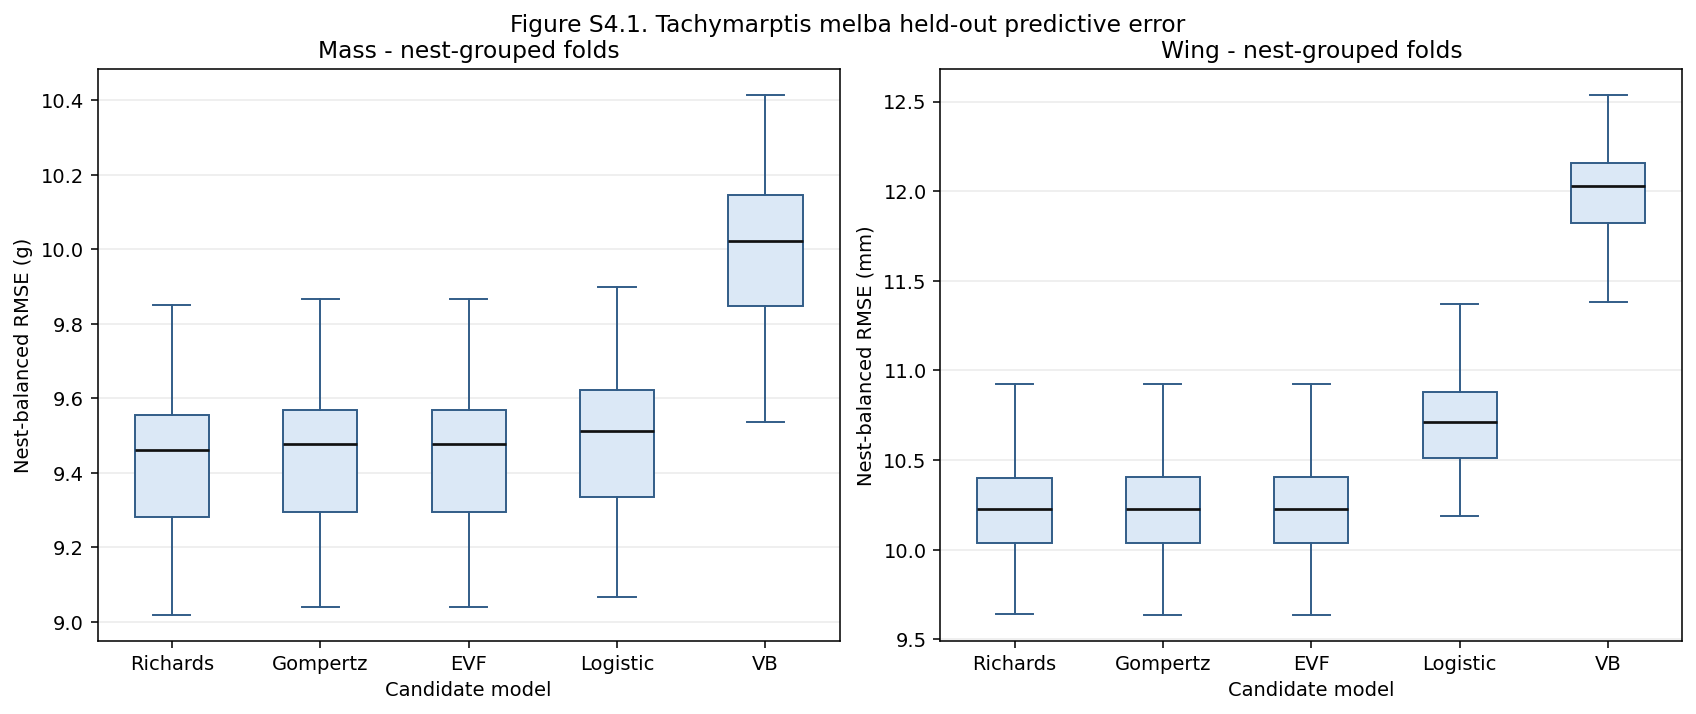

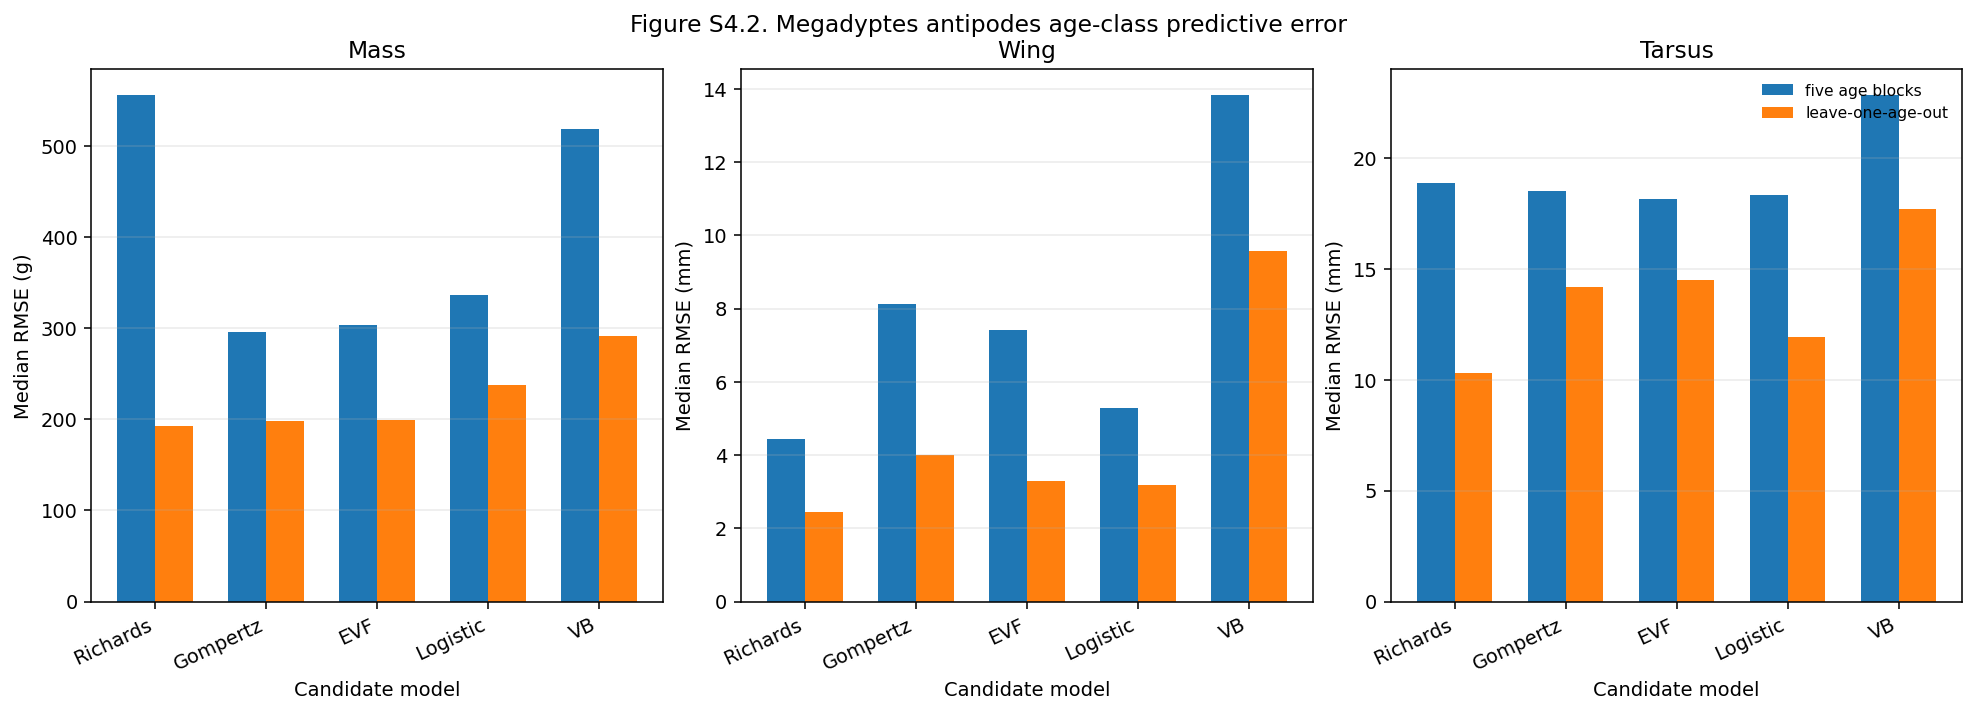

In [8]:
# Figure S4.1: fold-level boxplots for T. melba.
nest_folds = tmelba_cv[tmelba_cv["Scheme"] == "nest-grouped 5-fold x 10"].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for ax, trait in zip(axes, ["mass", "wing"]):
    sub = nest_folds[nest_folds["Trait"] == trait]
    models = [m for m in MODEL_ORDER if m in set(sub["Model"])]
    data = [sub[sub["Model"] == m]["Balanced_RMSE"].dropna().to_numpy() for m in models]
    ax.boxplot(data, tick_labels=[SHORT_NAMES.get(m, m) for m in models], showfliers=False, patch_artist=True,
               boxprops={"facecolor": "#dbe8f6", "edgecolor": "#325d88"},
               medianprops={"color": "#111111", "linewidth": 1.4},
               whiskerprops={"color": "#325d88"}, capprops={"color": "#325d88"})
    ax.set_title(f"{trait.capitalize()} - nest-grouped folds")
    ax.set_ylabel(f"Nest-balanced RMSE ({TRAIT_UNITS[trait]})")
    ax.set_xlabel("Candidate model")
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Figure S4.1. Tachymarptis melba held-out predictive error", y=1.03)
plt.show()

# Figure S4.2: age-class validation for M. antipodes.
plot_peng = penguin_display.copy()
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), constrained_layout=True)
for ax, trait in zip(axes, ["mass", "wing", "tarsus"]):
    sub = plot_peng[plot_peng["Trait"] == trait].copy()
    schemes = list(sub["Scheme"].drop_duplicates())
    x = np.arange(len(MODEL_ORDER))
    width = 0.34
    for j, scheme in enumerate(schemes):
        vals = []
        for model in MODEL_ORDER:
            match = sub[(sub["Scheme"] == scheme) & (sub["Model"] == model)]
            vals.append(float(match["RMSE_median"].iloc[0]) if len(match) else np.nan)
        offset = (j - (len(schemes) - 1) / 2) * width
        ax.bar(x + offset, vals, width=width, label=scheme.replace("five-contiguous-age-blocks", "five age blocks"))
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT_NAMES.get(m, m) for m in MODEL_ORDER], rotation=25, ha="right")
    ax.set_title(trait.capitalize())
    ax.set_ylabel(f"Median RMSE ({TRAIT_UNITS[trait]})")
    ax.set_xlabel("Candidate model")
    ax.grid(axis="y", alpha=0.25)
axes[-1].legend(frameon=False, loc="upper right", fontsize=8)
fig.suptitle("Figure S4.2. Megadyptes antipodes age-class predictive error", y=1.03)
plt.show()


## Interpretation

The validation is strongest for *T. melba* body mass. Richards was consistently favoured by AICc in the training folds and also performed well when predicting held-out nests. Wing length showed the same AICc preference, although the held-out error distributions overlapped more with other sigmoidal models, so the predictive separation is more cautious.

In *M. antipodes*, the age-class checks are broadly consistent with the AICc-supported curves. Body mass supports Gompertz, but logistic remains close enough by AICc that the result is better read as support for a small set of plausible curves rather than as a strict single-model outcome. Across both datasets, the main conclusion is bounded: AICc identifies the best-supported candidate within the analysed sample, and predictive checks show where that support is also reflected in held-out performance.
